In [6]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
import numpy as np

In [9]:

bias_path = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/6751858rj_bia.fits"
dark_path = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/25716219j_drk.fits"
exptime = 2028

bias = fits.open(bias_path)
dark = fits.open(dark_path)
bias.info()

Filename: ../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/6751858rj_bia.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     145   ()      
  1  SCI           1 ImageHDU        95   (4144, 2068)   float32   
  2  ERR           1 ImageHDU        48   (4144, 2068)   float32   
  3  DQ            1 ImageHDU        40   (4144, 2068)   int16   
  4  SCI           2 ImageHDU        95   (4144, 2068)   float32   
  5  ERR           2 ImageHDU        48   (4144, 2068)   float32   
  6  DQ            2 ImageHDU        40   (4144, 2068)   int16   


$
 z_d + z_p + Az_t
$

In [10]:
# bias[0].header

In [11]:
# bias[3].header

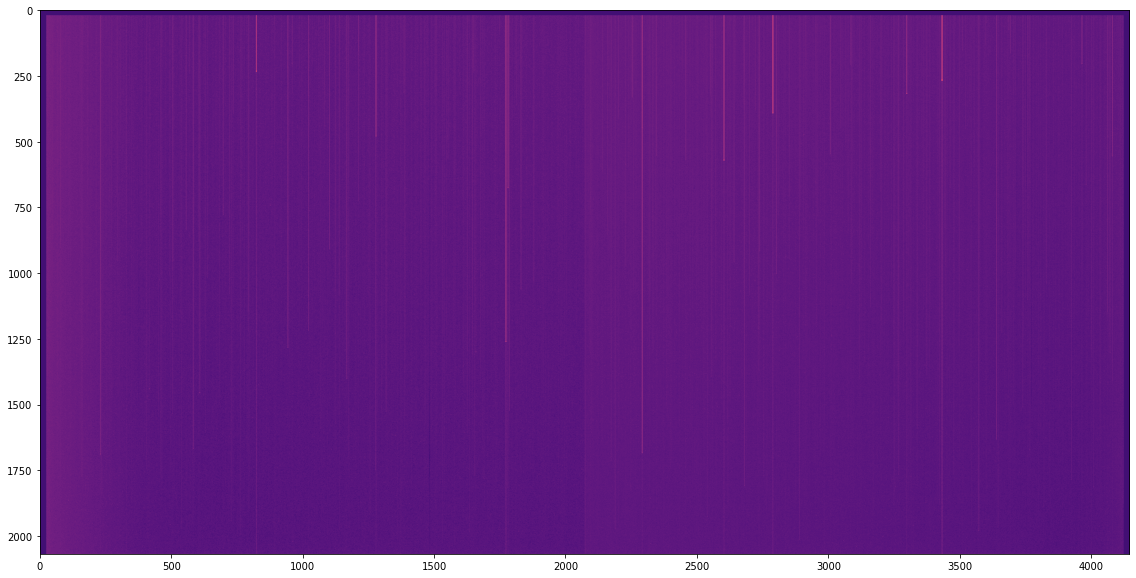

In [15]:
plt.figure(figsize=(20, 10))
plt.imshow(bias[4].data / exptime, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
# plt.colorbar()

In [16]:
# dark[0].header

In [17]:
# dark[1].data

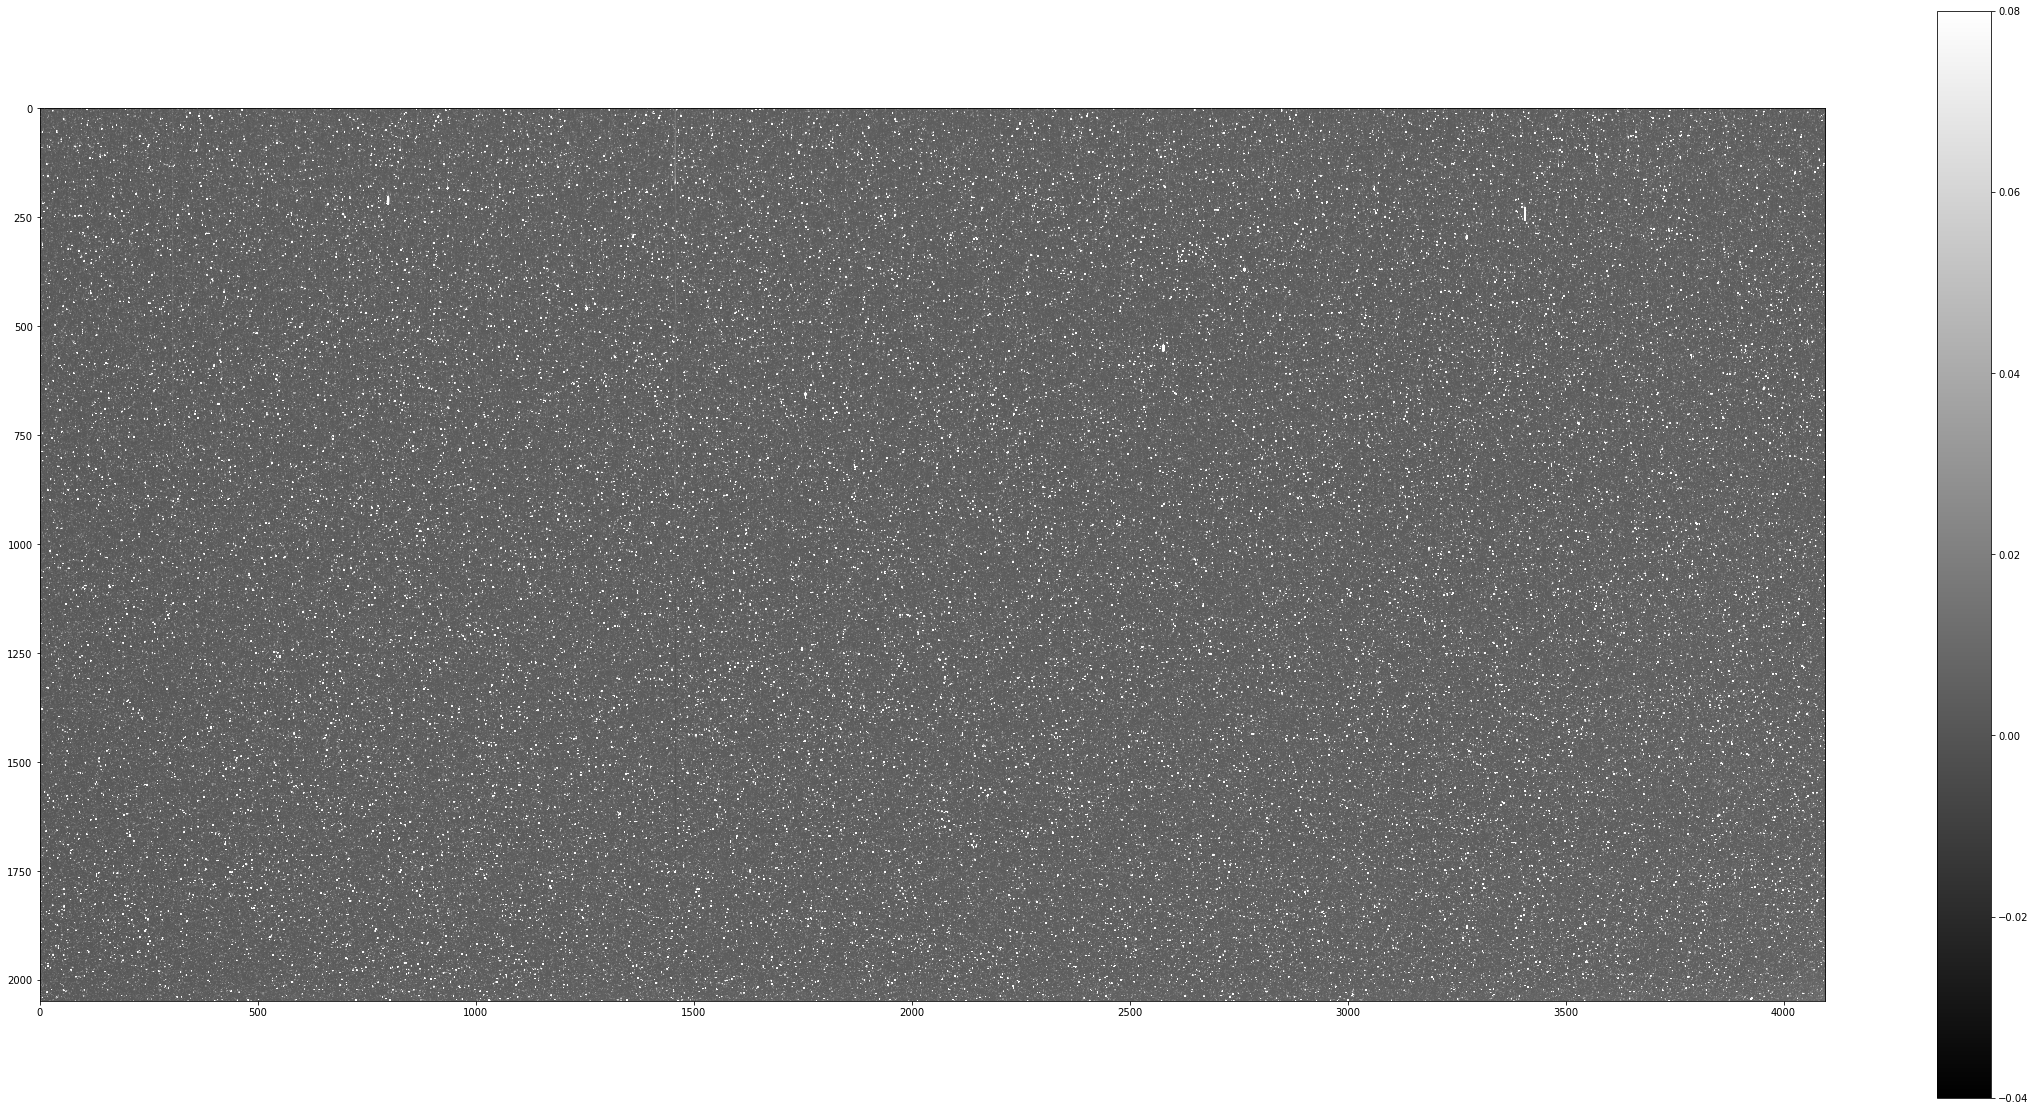

In [19]:
plt.figure(figsize=(40, 20))
plt.imshow(dark[4].data, cmap="gray", vmax=0.08, vmin=-0.04)
plt.colorbar()

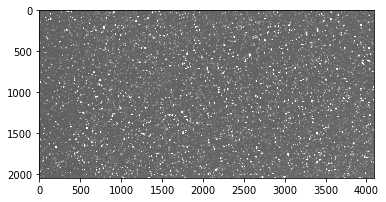

In [69]:
plt.imshow(dark[4].data, cmap="gray", vmax=0.08, vmin=-0.04)
# plt.colorbar()

In [56]:
# dark[1].header

left 2478.7292 2397.3484 64840.64 (2068, 2068)
right 2478.9004 2394.8918 64376.81 (2068, 2076)
left 2480.703 2410.241 65541.02 (2068, 2068)
right 2650.1138 2488.427 67414.91 (2068, 2076)
left 2480.3271 2395.3696 64840.574 (2068, 2068)
right 2481.0557 2393.9097 64376.637 (2068, 2076)
left 2483.1382 2409.241 65541.49 (2068, 2068)
right 2652.74 2490.4844 67415.39 (2068, 2076)
left 2480.157 2396.359 64840.68 (2068, 2068)
right 2480.6155 2393.9097 64376.754 (2068, 2076)
left 2481.033 2410.241 65541.125 (2068, 2068)
right 2663.704 2486.3696 67416.26 (2068, 2076)
left 2482.3347 2401.3062 64840.793 (2068, 2068)
right 2481.053 2390.9626 64376.59 (2068, 2076)
left 2481.583 2406.2407 65542.5 (2068, 2068)
right 2668.553 2493.5706 67413.53 (2068, 2076)


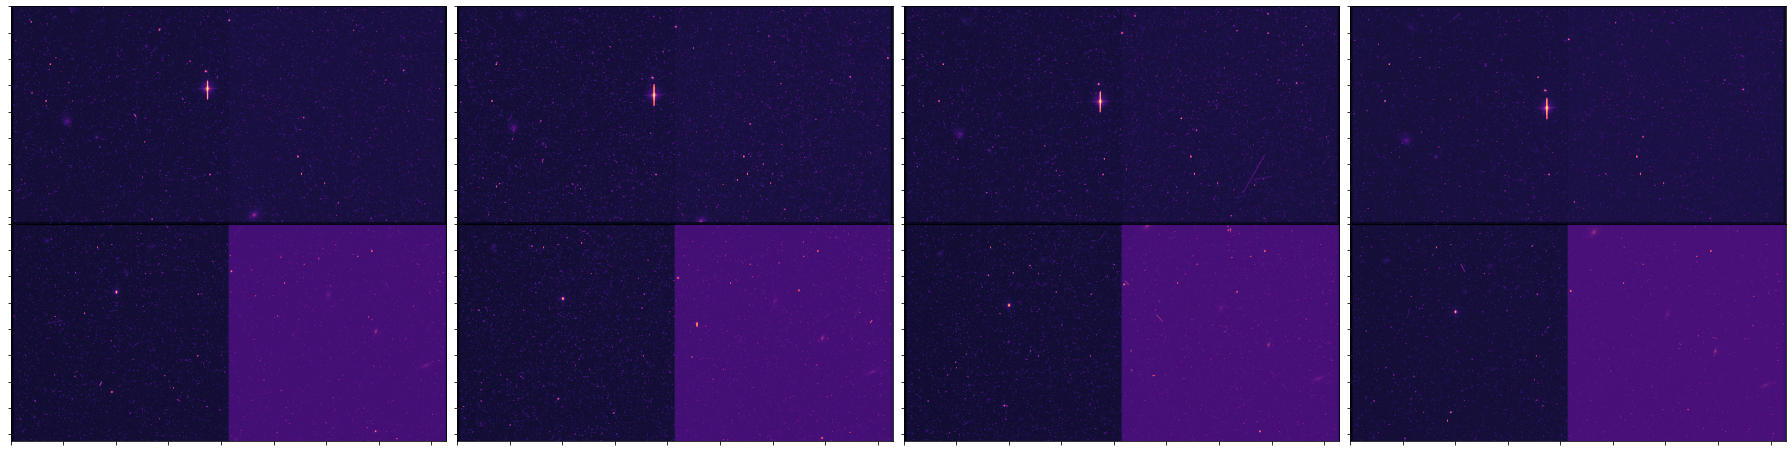

In [20]:

cutout_size = 64

path1 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybhq_raw.fits"
path2 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybkq_raw.fits"
path3 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybnq_raw.fits"
path4 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybyq_raw.fits"


filenames = [path1, path2, path3, path4]

img_set = []

tPlot, axes = plt.subplots(
        nrows=2, ncols=4, sharex=True, sharey=True,figsize=(2*16,8)
        )

# From HST 
# gain_a = 1.57
# gain_b = 1.57
# gain_c = 1.60
# gain_d = 1.58
# From bias file
gain_a = bias[0].header["ATODGNA"]
gain_b = bias[0].header["ATODGNB"]
gain_c = bias[0].header["ATODGNC"]
gain_d = bias[0].header["ATODGND"]


for i, filename in enumerate(filenames):
    for j, k in enumerate([1, 4]): 
        data_fits = fits.open(filename)
        exptime = data_fits[0].header["EXPTIME"]
        # print(data_fits.info())
        img = data_fits[k].data.astype(np.float32)
        if k == 1:
            img -= bias[1].data
            img[:, :2068] /= gain_c #* exptime
            img[:, 2068:] /= gain_d #* exptime
        elif k == 4:
            img -= bias[4].data
            img[:, :2068] /= gain_a #* exptime
            img[:, 2068:] /= gain_b #* exptime
        print("left", img[:, :2068].mean(), img[:, :2068].min(), img[:, :2068].max(), img[:, :2068].shape)
        print("right", img[:, 2068:].mean(), img[:, 2068:].min(), img[:, 2068:].max(), img[:, 2068:].shape)



        axes[j, i].imshow(img, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
        # axes[j, i].imshow(img - 4.96, cmap="gray", vmin=-0.04, vmax=0.08)

        axes[j, i].set_xticklabels([])
        axes[j, i].set_yticklabels([])
        img_set.append(img)

plt.subplots_adjust(wspace=0, hspace=0)
# plt.savefig('hst_snapshots.png')


In [163]:
def create_random_crops(img, crop_height, crop_width, num_crops):
    """
    This function creates a list of random crops from an image.

    Args:
    image_path: str. Path to the image.
    crop_height: int. Height of the crops.
    crop_width: int. Width of the crops.
    num_crops: int. Number of random crops to create.

    Returns:
    List of crops.
    """

    # Get the height of the image
    image_height = img.shape[0]
    image_width = img.shape[1]

    # Define a list to hold the crops
    crops = []

    for _ in range(num_crops):
        # Randomly choose the starting x and y coordinates for the crop
        start_x = np.random.randint(0, image_width - crop_width)
        start_y = np.random.randint(0, image_height - crop_height)

        # Get the crop
        crop = img[start_y:start_y+crop_height, start_x:start_x+crop_width]

        # Append the crop to the list
        crops.append(crop)

    return crops

# dark_crops = create_random_crops(dark[1].data[:, :2048], 64, 64, 1000)
crops = create_random_crops(fits.open(path1)[1].data[:, :2048], 64, 64, 1000)

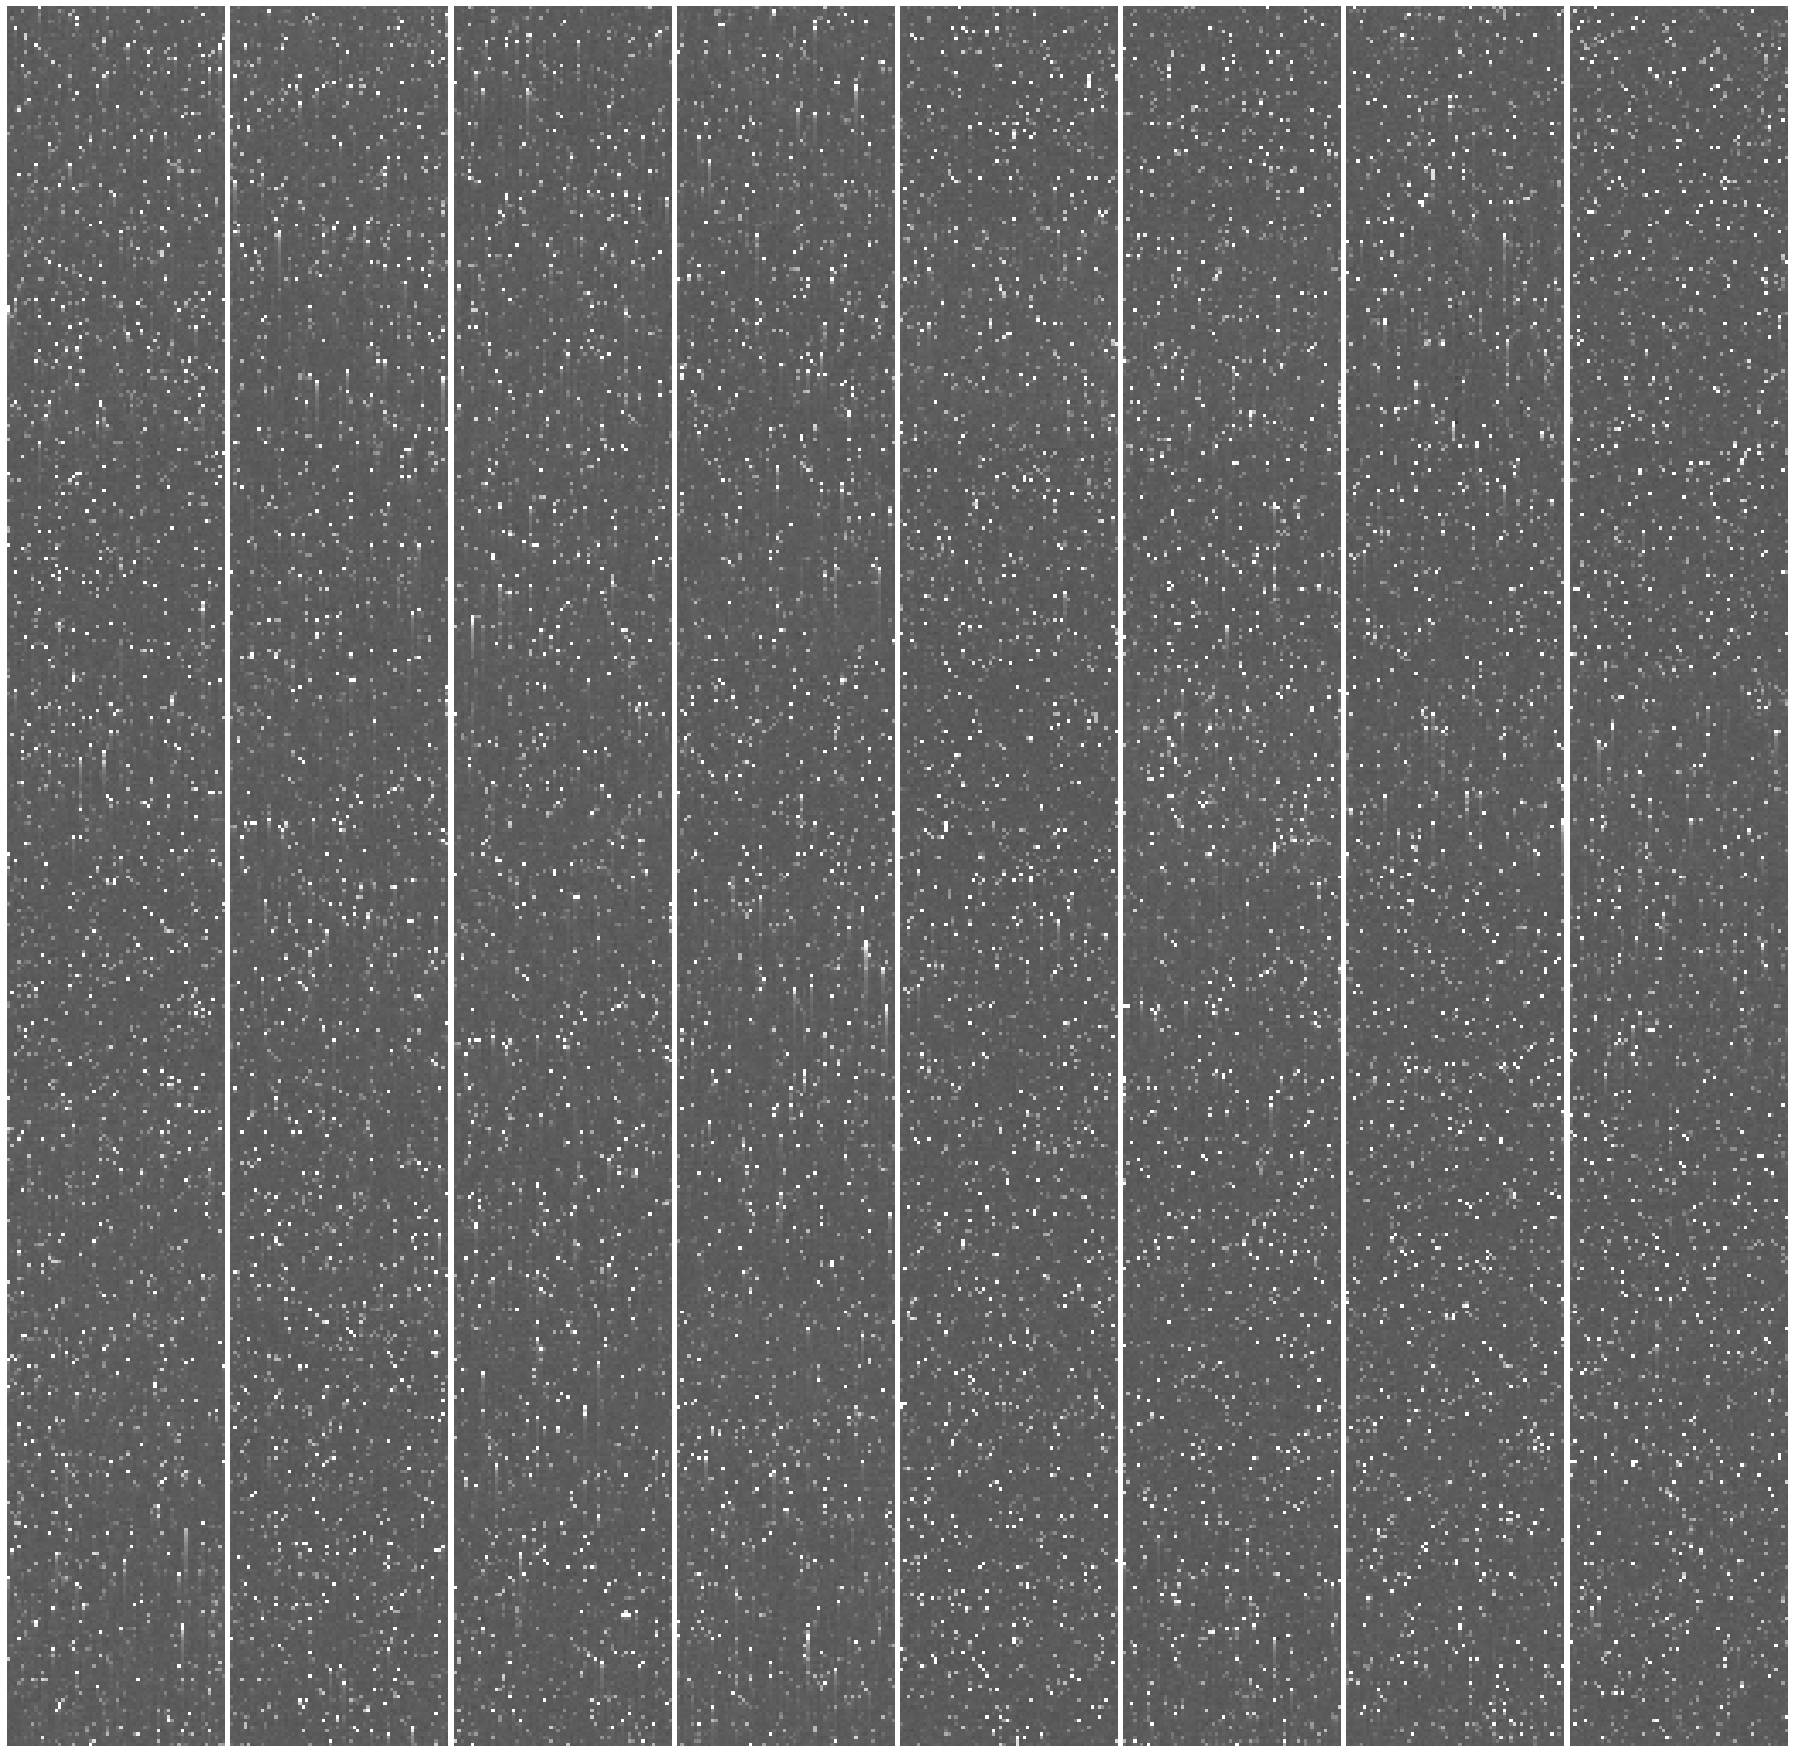

In [161]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

for i in range(8):
    for j in range(8):
        k = np.random.randint(1000)
        axs[i, j].imshow(dark_crops[k], cmap="gray", vmin=-0.04, vmax=0.08)
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

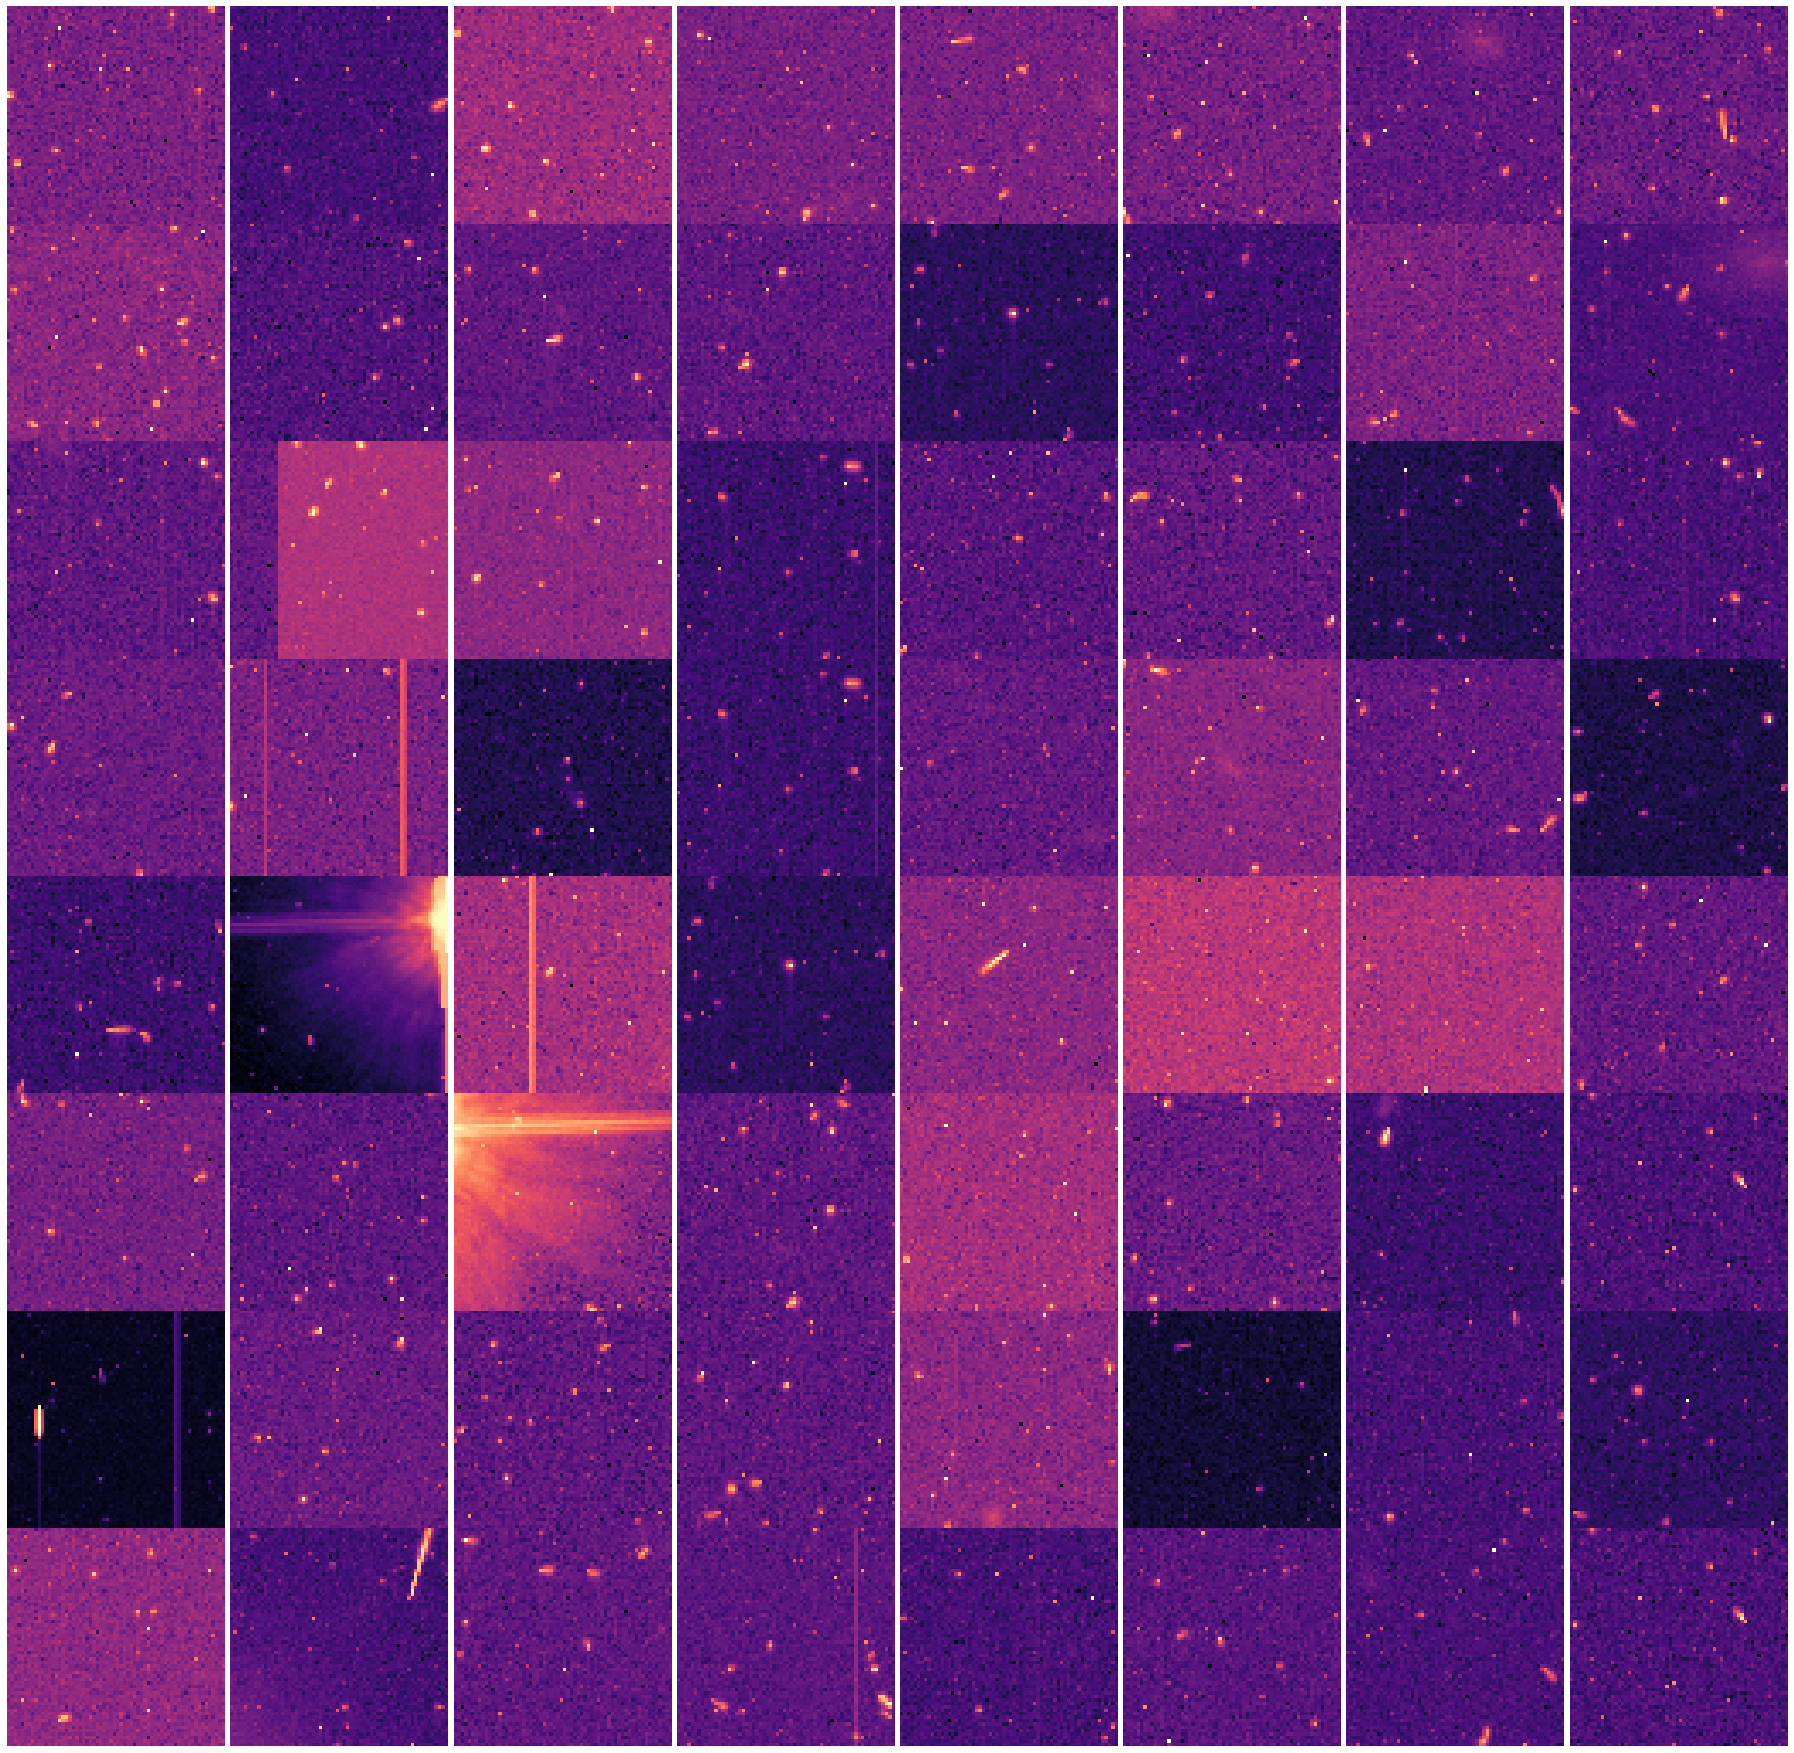

In [164]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

for i in range(8):
    for j in range(8):
        k = np.random.randint(1000)
        axs[i, j].imshow(crops[k], cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)